# Chapter 8 Lab: Financial Documents, Covenants, and Suitability

**Runtime:** 2–3 minutes · **Difficulty:** intermediate · **Credentials:** none

This notebook combines text extraction with deterministic financial controls. It extracts
loan terms, recomputes covenant headroom, retrieves a time-valid liquidity passage, and
applies client-suitability rules to hypothetical proposals.


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/08_document_intelligence_and_suitability.ipynb) · [View source on GitHub](https://github.com/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/08_document_intelligence_and_suitability.ipynb)

The next cell is inert outside Google Colab. In Colab it retrieves the official repository and installs the local package before the lab runs.


In [1]:
# Google Colab bootstrap — inert during local and CI execution.
import os as _os
from pathlib import Path as _Path
import subprocess as _subprocess
import sys as _sys

try:
    import google.colab as _google_colab  # type: ignore[import-not-found]
except ImportError:
    _in_colab = False
else:
    _in_colab = True

if _in_colab:
    _repo = _Path("/content/LLMs-in-Finance")
    if _repo.exists() and not (_repo / ".git").is_dir():
        raise RuntimeError(f"Refusing to overwrite non-repository path: {_repo}")
    if _repo.exists():
        _subprocess.run(
            ["git", "-C", str(_repo), "fetch", "--depth", "1", "origin", "main"],
            check=True,
        )
        _subprocess.run(
            ["git", "-C", str(_repo), "checkout", "--detach", "FETCH_HEAD"],
            check=True,
        )
    else:
        _subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "main",
                "https://github.com/PacktPublishing/LLMs-in-Finance.git",
                str(_repo),
            ],
            check=True,
        )
    _subprocess.run(
        [_sys.executable, "-m", "pip", "install", "-q", "-e", str(_repo)],
        check=True,
    )
    _os.chdir(_repo)


## Learning objectives

- preserve exact contract terms and spans;
- separate extraction from covenant calculation;
- escalate missing or breached terms;
- synthesize contract and filing evidence; and
- keep advisory text behind deterministic suitability controls.


In [2]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from finllm_lab import Document, canonical_hash, seed_everything
from finllm_lab.documents import covenant_checks, extract_contract_terms, suitability_gate
from finllm_lab.plotting import COLORS, finish, set_finance_theme
from finllm_lab.rag import BM25Index

set_finance_theme()
seed_everything(808)
contracts = [json.loads(line) for line in (ROOT / "data" / "contracts.jsonl").read_text().splitlines()]
clients = json.loads((ROOT / "data" / "client_profiles.json").read_text())


## 1. Extract terms, then calculate

The text component proposes structured terms. The numerical component accepts only typed
values and recomputes compliance.


In [3]:
required_terms = {
    "facility_amount_mn",
    "maturity_years",
    "spread_bps",
    "max_leverage",
    "min_coverage",
    "currency",
}
contract_rows, check_rows = [], []
for contract in contracts:
    terms = extract_contract_terms(contract["text"])
    contract_rows.append(
        {
            "contract_id": contract["contract_id"],
            "ticker": contract["ticker"],
            **terms,
            "extraction_complete": (
                required_terms.issubset(terms) and "currency_conflict" not in terms
            ),
        }
    )
    for check in covenant_checks(
        terms,
        contract["observed_leverage"],
        contract["observed_interest_coverage"],
    ):
        check_rows.append(
            {
                "ticker": contract["ticker"],
                "covenant": check.name,
                "observed": check.observed,
                "threshold": check.threshold,
                "operator": check.operator,
                "headroom": check.headroom,
                "compliant": check.compliant,
            }
        )
terms_table = pd.DataFrame(contract_rows)
checks_table = pd.DataFrame(check_rows)
display(terms_table)
checks_table


,contract_id,ticker,facility_amount_mn,maturity_years,spread_bps,max_leverage,min_coverage,currency,extraction_complete
0,facility-ACME-01,ACME,450.0,4.0,185.0,3.50,2.25,USD,True
1,facility-NIMB-01,NIMB,300.0,5.0,210.0,3.00,2.75,USD,True
2,facility-ORBT-01,ORBT,220.0,3.0,165.0,2.75,3.00,EUR,True
3,facility-VELA-01,VELA,600.0,4.0,240.0,4.00,1.80,USD,True


,ticker,covenant,observed,threshold,operator,headroom,compliant
0,ACME,leverage,3.18,3.50,<=,0.32,True
1,ACME,interest_coverage,2.61,2.25,>=,0.36,True
2,NIMB,leverage,3.14,3.00,<=,-0.14,False
3,NIMB,interest_coverage,2.82,2.75,>=,0.07,True
4,ORBT,leverage,2.41,2.75,<=,0.34,True
5,ORBT,interest_coverage,3.34,3.00,>=,0.34,True
6,VELA,leverage,3.76,4.00,<=,0.24,True
7,VELA,interest_coverage,1.69,1.80,>=,-0.11,False


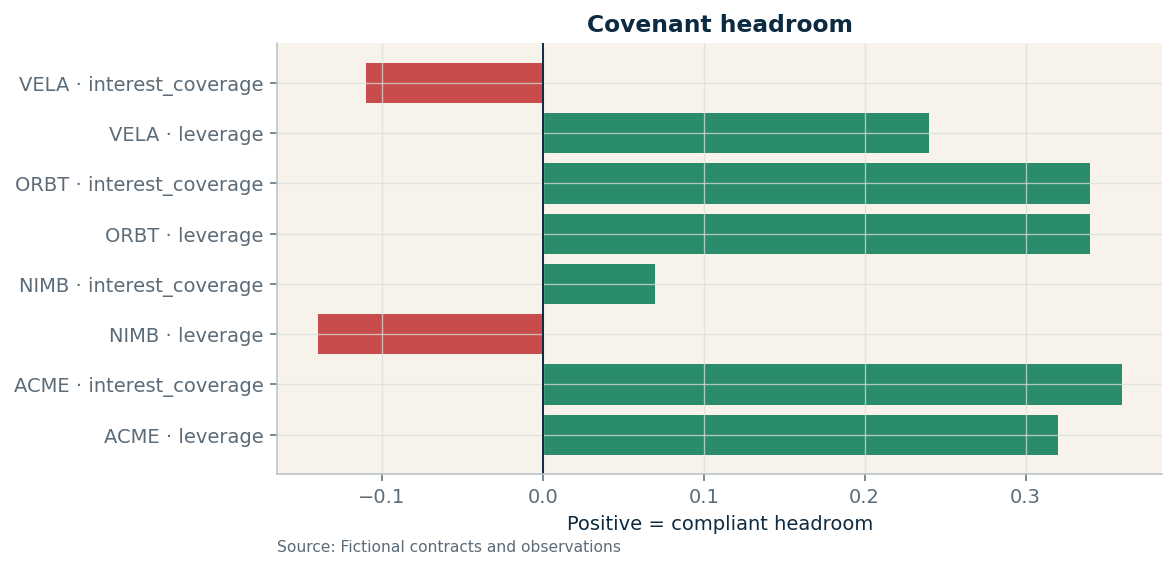

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
colors = [COLORS["green"] if ok else COLORS["red"] for ok in checks_table["compliant"]]
labels = checks_table["ticker"] + " · " + checks_table["covenant"]
ax.barh(labels, checks_table["headroom"], color=colors)
ax.axvline(0, color=COLORS["navy"], linewidth=1)
ax.set(title="Covenant headroom", xlabel="Positive = compliant headroom")
finish(ax, "Fictional contracts and observations")
plt.tight_layout()


## 2. Fail closed on an incomplete contract


In [5]:
incomplete_text = (
    "The borrower enters a USD revolving facility of $100 million with a maturity of 3 years. "
    "The leverage ratio shall not exceed 3.25x."
)
incomplete_terms = extract_contract_terms(incomplete_text)
required = {
    "facility_amount_mn",
    "maturity_years",
    "spread_bps",
    "max_leverage",
    "min_coverage",
    "currency",
}
missing = sorted(required - set(incomplete_terms))
incomplete_decision = {
    "status": "escalate" if missing else "continue",
    "missing_fields": missing,
    "extracted_terms": incomplete_terms,
}
incomplete_decision


{'extracted_terms': {'currency': 'USD',
                     'facility_amount_mn': 100.0,
                     'maturity_years': 3.0,
                     'max_leverage': 3.25},
 'missing_fields': ['min_coverage', 'spread_bps'],
 'status': 'escalate'}

## 3. Join contract logic with filing evidence

A covenant calculation is only as current as the observations behind it. We retrieve the
latest fictional liquidity section for VELA and attach its evidence identifier.


In [6]:
filing_rows = [json.loads(line) for line in (ROOT / "data" / "filings.jsonl").read_text().splitlines()]
filing_docs = tuple(
    Document(
        document_id=row["document_id"],
        text=row["text"],
        source=row["source"],
        available_at=pd.Timestamp(row["available_at"]).to_pydatetime(),
        issuer=row["ticker"],
        section=row["section"],
        metadata={"period": row["period"]},
    )
    for row in filing_rows
)
decision_time = pd.Timestamp("2026-02-20T18:00:00Z")
liquidity_evidence = BM25Index(filing_docs).search(
    "VELA net leverage and interest coverage 2025Q4",
    k=3,
    decision_time=decision_time.to_pydatetime(),
    issuer="VELA",
    section="liquidity",
    period="2025Q4",
)
pd.DataFrame(
    [
        {
            "document_id": item.document_id,
            "score": item.score,
            "passage": item.passage,
        }
        for item in liquidity_evidence
    ]
)


,document_id,score,passage
0,filing-VELA-2025Q4-liquidity,1.0,"Quarter-end cash was $281.8 million and gross debt was $1,257.8 million. Net leverage was 2.48x and interest coverage was 2.58x. Management stated that liquidity was sufficient for the current operating plan."


## 4. Suitability is a deterministic constraint


In [7]:
proposals = [
    {
        "proposal_id": "short-duration-bond",
        "risk_score": 2,
        "horizon_years": 3,
        "liquidity_days": 2,
        "complex": False,
    },
    {
        "proposal_id": "private-credit-note",
        "risk_score": 4,
        "horizon_years": 10,
        "liquidity_days": 120,
        "complex": True,
    },
]
suitability_rows = []
for profile in clients:
    for proposal in proposals:
        status, reasons = suitability_gate(profile, proposal)
        suitability_rows.append(
            {
                "client": profile["client_id"],
                "proposal": proposal["proposal_id"],
                "status": status,
                "reasons": "; ".join(reasons) or "none",
            }
        )
suitability = pd.DataFrame(suitability_rows)
suitability


,client,proposal,status,reasons
0,client-conservative,short-duration-bond,allow,none
1,client-conservative,private-credit-note,reject,proposal risk exceeds documented tolerance; proposal horizon exceeds client horizon; proposal liquidity is incompatible with client needs; complex-product approval is absent
2,client-balanced,short-duration-bond,allow,none
3,client-balanced,private-credit-note,reject,proposal risk exceeds documented tolerance; proposal horizon exceeds client horizon; proposal liquidity is incompatible with client needs; complex-product approval is absent
4,client-sophisticated,short-duration-bond,allow,none
5,client-sophisticated,private-credit-note,allow,none


## 5. Assemble a review packet


In [8]:
vela_checks = checks_table[checks_table["ticker"] == "VELA"]
review_packet = {
    "case_id": "credit-review-VELA-2025Q4",
    "decision_time": decision_time.isoformat(),
    "contract_id": "facility-VELA-01",
    "extraction_complete": bool(
        terms_table.loc[terms_table["ticker"] == "VELA", "extraction_complete"].iloc[0]
    ),
    "covenant_results": vela_checks.to_dict("records"),
    "evidence_ids": [item.evidence_id for item in liquidity_evidence],
    "status": "escalate" if (~vela_checks["compliant"]).any() else "review",
    "allowed_actions": (
        ["request_updated_financials", "escalate_to_credit_officer"]
        if (~vela_checks["compliant"]).any()
        else ["close_as_clear", "request_updated_financials"]
    ),
}
review_packet["fingerprint"] = canonical_hash(review_packet)
review_packet


{'allowed_actions': ['request_updated_financials', 'escalate_to_credit_officer'],
 'case_id': 'credit-review-VELA-2025Q4',
 'contract_id': 'facility-VELA-01',
 'covenant_results': [{'compliant': True,
                       'covenant': 'leverage',
                       'headroom': 0.2400000000000002,
                       'observed': 3.76,
                       'operator': '<=',
                       'threshold': 4.0,
                       'ticker': 'VELA'},
                      {'compliant': False,
                       'covenant': 'interest_coverage',
                       'headroom': -0.1100000000000001,
                       'observed': 1.69,
                       'operator': '>=',
                       'threshold': 1.8,
                       'ticker': 'VELA'}],
 'decision_time': '2026-02-20T18:00:00+00:00',
 'evidence_ids': ['ev::filing-VELA-2025Q4-liquidity'],
 'extraction_complete': True,
 'fingerprint': '81038b8408a923c82b43ea200357f0204a551d13ad79969c18aa27e858489b

## Takeaways

- Extracted text is an input to calculation, not the calculation itself.
- Missing terms and negative headroom are explicit escalation conditions.
- Multi-document reasoning needs timestamps and evidence IDs across every source.
- Suitability rules belong outside generative prose.

**Challenge:** add amendment precedence so a later contract amendment overrides only the
terms it explicitly changes.
